### CC-PULPO Case Study: Ammonia Production
This notebook showcases the application of CC-PULPO and the broader uncertainty framework to an ammonia production case study. Here, two epistemic uncertainty iterations are presented.

In [ ]:
# Import helpers to keep main script clean
import importlib
import a0_uncertainty_utils as unc_utils
import a0_uncertainty_plots as unc_plots

import bw2data as bd
import bw2io as bi
from bw2io.package import BW2Package

from pulpo import pulpo 
from pulpo.utils.uncertainty import processor
import numpy as np
import pandas as pd
from copy import deepcopy

from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method

#### LCI Implementation
First, create a project and import the **ecoinvent 3.10 (cutoff)** background LCI. Set your ecoinvent credentials as environment variables (_Windows: run Command Prompt as Administrator_):

```
setx ECOINVENT_USERNAME "your_username"
setx ECOINVENT_PASSWORD "your_password"
```

*Restart VS Code or your machine after setting these variables.*

In [ ]:
PROJECT = "ammonia_last"
EI_NAME = "ecoinvent-3.10-cutoff"

#username = "your_username"  # Replace with actual username
#password = "your_password"  # Replace with actual password

# 1) Ensure project exists / is selected
bd.projects.set_current(PROJECT)

# 2) Import ecoinvent 3.10 cutoff if missing
if EI_NAME in bd.databases:
    print(f"Database '{EI_NAME}' already exists in project '{bd.projects.current}'.")
else:
    username, password = unc_utils.get_ecoinvent_credentials()
    bi.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",
        username=username,
        password=password,
    )
    print(f"Database '{EI_NAME}' installed successfully.")

Next, import the **ammonia foreground LCI** from the Excel spreadsheet.

In [ ]:
# Path to your Excel file
excel_path = r"data/ammonia.xlsx"
FG_NAME = "ammonia"

if FG_NAME in bd.databases:
    print(f"Database '{FG_NAME}' already exists in project '{bd.projects.current}'.")
else:
    fg_db = bi.ExcelImporter(excel_path)
    fg_db.apply_strategies()
    fg_db.match_database(fields=["name", "unit", "reference product", "location"])
    fg_db.match_database("ecoinvent-3.10-cutoff", fields=["name", "unit", "location", "reference product"])
    biosphere_db = [db for db in bd.databases if "biosphere" in db and "3.10" in db][0]
    fg_db.match_database(biosphere_db, fields=["name", "categories", "location"])
    fg_db.statistics()
    fg_db.write_database()
    print(f"Database '{FG_NAME}' installed successfully.")

#### LCIA Implementation (GWP Uncertainty)

This method has been obtained and adapted (introduction of -1 for biogenic carbon) from [Github](https://github.com/aleksandra-kim/gwp_uncertainties)

In [ ]:
METHOD = ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
bd.projects.set_current(PROJECT)

if METHOD in bd.methods:
    print(f"Method '{METHOD}' already exists in the project.")
else:
    BW2Package.import_file("data/ipcc_uncertain.bw2package")
    print("IPCC 2013 GWP with uncertainty characterization factors added successfully.")

### Case Study Definition

First, define some helper functions and specify missing project parameters.

In [ ]:
# PROJECT; EI_NAME; FG_NAME; METHOD - Are all previously defined!
METHOD = str(METHOD)
DATABASES = [EI_NAME, FG_NAME]
DIRECTORY = "develop_tests"

def create_pulpo_worker(project, database, method, directory):
    """
    Create and initialize a PULPO optimizer instance.
    Returns: pulpo.PulpoOptimizer: Configured PULPO worker instance
    """
    # Create PulpoOptimizer instance
    pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)
    pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
    
    # Import LCI data
    pulpo_worker.get_lci_data()
    return pulpo_worker

def get_single_process(worker, query, prefer_locations=("RER", "Europe", "GLO")):
    """Deterministic process retrieval to avoid order issues."""
    matches = worker.retrieve_processes(processes=query)
    if not matches:
        raise ValueError(f"No process found for query: {query}")
    # Try preferred locations first
    for loc in prefer_locations:
        for p in matches:
            if getattr(p, "location", None) == loc or loc in str(p):
                return p
    return sorted(matches, key=lambda x: str(x))[0]

Then, define the case study by specifying **demand**, **choices**, and **constraints**.

In [ ]:
def define_ammonia_problem(pulpo_worker):
    """
    Define the ammonia production optimization problem with streamlined configuration.
    """
    # Choice definitions with capacities bound per-label
    choice_config = {
        "biogas": {
            "processes": [
                "anaerobic digestion of agricultural residues",
                "anaerobic digestion of sequential crop",
                "anaerobic digestion of animal manure",
            ],
            # 2030 EU-27 potentials from biomethane shares (38 bcm total; 24% ag, 21% sequential, 32% manure),
            # converted to raw biogas assuming ~57% CH₄ → 16.0 & 14.0 bcm & 21.3 bcm ≈ 1.60e10 & 1.40e10 & 2.13e10 m³/yr.
            "capacities": [1.60e10, 1.40e10, 2.13e10],
        },
        "biomethane": {
            "processes": [
                "upgrading water scrubbing (CCS)",
                "upgrading water scrubbing",
                "upgrading chemical scrubbing",
                "upgrading chemical scrubbing (CCS)",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20],
        },
        "methane": {
            "processes": ["market for methane fg", "market for biomethane"],
            "capacities": [1e20, 1e20],
        },
        "heat": {
            "processes": ["heat from methane", "heat from methane (CCS)", "heat from hydrogen"],
            "capacities": [1e20, 1e20, 1e20],
        },
        "hydrogen": {
            "processes": [
                "methane pyrolysis",
                "steam methane reforming",
                "steam methane reforming (CCS)",
                "plastics gasification",
                "plastics gasification (CCS)",
                "alkaline electrolysis",
                "PEM electrolysis",
            ],
            # Methane pyrolysis capped to 10,000 t H2/yr (= 1.0e7 kg/yr); others left high for now.
            # "capacities": [3.0e8, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
            "capacities": [1e20, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
        },
        "ammonia": {
            "processes": [
                "steam reforming, integrated",
                "steam reforming, integrated (CCS)",
                "nitrogen + hydrogen",
            ],
            "capacities": [1e20, 1e20, 1e20],
        },
    }

    # Build choices with deterministic mapping
    choices = {}
    for category, cfg in choice_config.items():
        labels, caps = cfg["processes"], cfg["capacities"]
        if len(labels) != len(caps):
            raise ValueError(f"Length mismatch in '{category}': {len(labels)} labels vs {len(caps)} capacities")
        choices[category] = {get_single_process(pulpo_worker, lbl): cap for lbl, cap in zip(labels, caps)}

    # Demand (EU ammonia, kg/yr)
    demand_process = get_single_process(pulpo_worker, "market for ammonia")
    demand = {demand_process: 17.1e9}  # ~17.1 Mt/yr (EU)

    # Additional upper bounds (shared resources / feedstocks)
    waste_pp = get_single_process(pulpo_worker, "treatment of waste PP")
    waste_ps = get_single_process(pulpo_worker, "treatment of waste PS")
    ccs_process = get_single_process(pulpo_worker, "CCS 200km pipeline 1000m deep")

    upper_bounds = {
        waste_pp: 1e20,     #1.875e9,  # 25% of ~7.5 Mt PP post-consumer waste ≈ 1.875 Mt/yr
        waste_ps: 1e20,     #3.25e8,   # 25% of ~1.3 Mt PS waste ≈ 0.325 Mt/yr
        ccs_process: 1e20,  #5.0e9,    # 5 MtCO2/yr (10% of EU-27 2030 NZIA target)
    }
    
    # Instantiate the optimization problem
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    return choices, demand

def solve_and_summarize(pulpo_worker, file_name='ammonia_results'):
    # Solve optimization problem
    pulpo_worker.solve(solver_name="gurobi")
    
    # Extract and summarize results
    result_data = pulpo_worker.extract_results()
    pulpo_worker.summarize_results(zeroes=True)
    
    return result_data

Solve the base case, without consideration of any uncertainties.

In [ ]:
# Create and initialize PULPO worker
print("1. Creating PULPO worker...")
pulpo_worker = create_pulpo_worker(PROJECT, DATABASES, METHOD, DIRECTORY)

# Define the optimization problem
print("2. Defining optimization problem...")
choices, demand = define_ammonia_problem(pulpo_worker)

# Solve the problem and get results
print("3. Solving optimization problem...")
result_data = solve_and_summarize(pulpo_worker, file_name='ammonia_test')

print(f"✅ Setup complete: {sum(len(c) for c in choices.values())} alternatives across {len(choices)} categories")

### Ieration 0: Generic Uncertainty Treatment

In this iteration, no technology or availablity constraints are considered except for availability of waste feedstock. In a first step, the uncetainty data of the LCIs and LCIA method are analysed in order to proceed with the gap filling strategies.

In [ ]:
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=0.,
    scaling_vector_strategy='constructed_demand',
    plot_results=False,
    plot_n_top_processes=19,
)

Uncertainty gaps are filled using triangular distributions based on statistical analysis of existing uncertainties. Background data uses interpolated bounds, foreground inventories use scaling factors (0.5-1.95 ... obtained from ecoinvent) with upward skew, and random noise adds artificial variance. Characterization factors use only existing uncertainties without gap filling.

In [ ]:
unc_strategies = [
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.TriangluarBaseStrategy( # Assuming that the Foreground uncertainties are similar to the background ones
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        upper_scaling_factor = 0.95, # The same as from TriangularBoundInterpolationStrategy of EcoInvent
        lower_scaling_factor = .5, # The same as from TriangularBoundInterpolationStrategy of EcoInvent
        noise_interval={'min':.1, 'max':.1}
    ),
    # This is set to very low scaling factors to reflect that we assume only off-the-shelf uncertainty in CFs based on literature
    processor.TriangluarBaseStrategy( # Based on Chen et al. 2021 10-20% variation in CFs
    uncertain_param_type='Cf',
    uncertain_param_subgroup=METHOD,
    upper_scaling_factor = 0.0001,
    lower_scaling_factor = 0.0001,
    noise_interval={'min':.00, 'max':.00},
    inverse_bounds_for_negative_values = False # This means that the skew is always towards zero, indepent if value is larger or smaller to zero
    )
    ]


In [ ]:
pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, plot_results=False)

Solve the multi-objective optimization problem using epsilon-constrained method on the lambda parameter.

In [ ]:
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True)
lambda_epsilon_array = np.concatenate([np.arange(0.5, 0.9, 0.05), np.arange(0.9, 1.0, 0.01)])
results_CC_it0 = pulpo_worker.solve_CC_problem(lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, plot_results=False)

Visualize results

In [181]:
# Define abbreviations for legend entries visible in the plot
abbreviations = {
    # Biogas technologies
    "anaerobic digestion of animal manure | biogas | RER": "AD-Manure",
    "anaerobic digestion of agricultural residues | biogas | RER": "AD-Agri",
    "anaerobic digestion of sequential crop | biogas | RER": "AD-SeqCrop",
    
    # Biomethane upgrading
    "upgrading chemical scrubbing (CCS) | biomethane, 24 bar | RER": "Chem. Scrubbing+CCS",
    
    # Methane sources
    "market for biomethane | biomethane, 24 bar | RER": "Biomethane",
    
    # Heat sources
    "heat from hydrogen | heat | RER": "H₂ Heat",
    "heat from methane (CCS) | heat | RER": "CH₄ Heat+CCS",
    
    # Hydrogen production
    "steam methane reforming (CCS) | hydrogen | RER": "SMR+CCS",
    "plastics gasification (CCS) | hydrogen | RER": "Plastics gasif. (CCS)",
    
    # Ammonia production
    "steam reforming, integrated (CCS) | ammonia | RER": "SMR (Integrated)+CCS",
    "nitrogen + hydrogen | ammonia | RER": "N₂ + H₂",

    # Other
    "CCS 200km pipeline 1000m deep | CO2 stored | RER": "CCS pipeline",
}

Generating Pareto front plot from CC results...


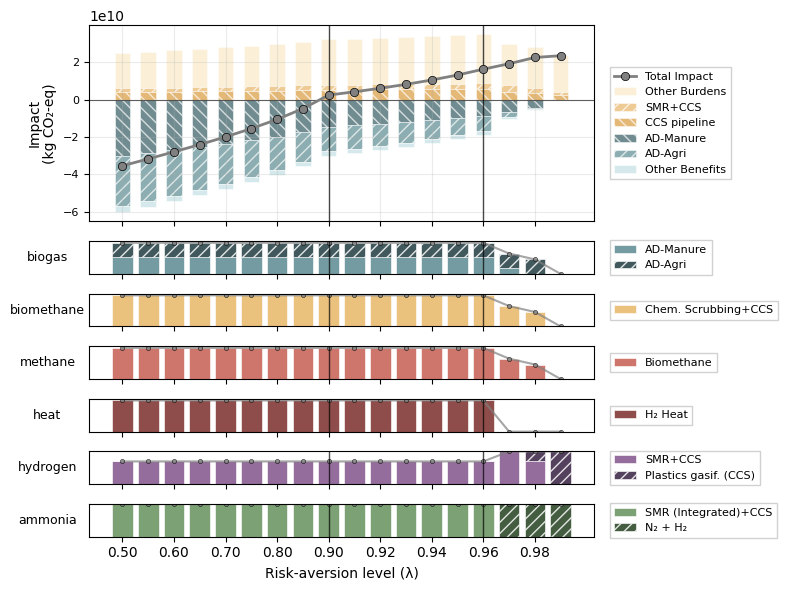

Pareto plot saved to: {'png': 'develop_tests\\pareto_and_choices_combined_it0.png', 'svg': 'develop_tests\\pareto_and_choices_combined_it0.svg'}


In [184]:
# Plot Pareto / CC results from results_CC
print('Generating Pareto front plot from CC results...')
plot_path = unc_plots.plot_pareto_from_results(
    results_CC_it0, 
    results_dir=DIRECTORY, 
    lambda_range=(0.5, 1.0),
    legend_abbreviations=abbreviations,
    suffix='_it0',
)
print(f'Pareto plot saved to: {plot_path}')

#### Global Sensitivity Analysis

We perform Global Sensitivity Analysis (GSA) using Sobol indices to identify the most influential uncertain parameters for different risk-aversion levels (λ values).

##### GSA Experiment 1: λ = 0.5

In [ ]:
pulpo_worker_gsa = deepcopy(pulpo_worker)

In [ ]:
pulpo_worker_gsa.import_and_filter_uncertainty_data(
    cutoff=0.000019, # removes processes to 1% impact contribution loss
    scaling_vector_strategy='naive',
    result_data=results_CC_it0[0.5],
    plot_results=False,
    plot_n_top_processes=19
)

pulpo_worker_gsa.apply_uncertainty_strategies(strategies=unc_strategies)

In [ ]:
total_Si, sensitivity_indices = pulpo_worker_gsa.run_gsa(
    result_data=results_CC_it0[0.5],
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=False,
    top_sensitivity_amt=20
)

In [ ]:
inv_map = pulpo_worker.lci_data["intervention_map_metadata"]
proc_map = pulpo_worker.lci_data["process_map_metadata"]

In [149]:
# Process GSA results using utility function
gsa_df, sum_top_5_st, remaining_contribution = unc_utils.process_gsa_results(
    total_Si, inv_map, proc_map, top_n=5
)

# Print summary
#unc_plots.print_gsa_summary(gsa_df, print_mapping_reference=True)

c:\Users\Fabian\Documents\Postdoc\Python\pulpo\pulpo\notebooks\a0_uncertainty_utils.py:112: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


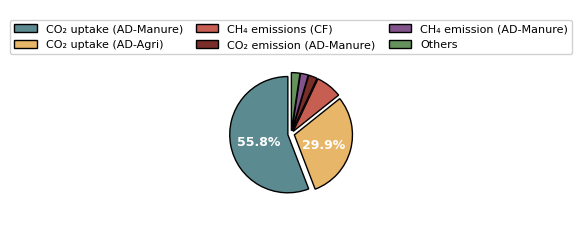

In [153]:
# Create pie chart using utility function
plot_info = unc_plots.plot_gsa_pie_chart(
    gsa_df, 
    figsize=(3, 6),
    results_dir=DIRECTORY,
    save_plot=True,
    show_plot=True,
    lambda_value=0.5,
)

if plot_info.get('pie_chart'):
    print(f"GSA pie chart saved to: {plot_info['pie_chart']}")

##### GSA Experiment 2: λ = 0.99

Now we repeat the Global Sensitivity Analysis for the high risk-aversion scenario (λ = 0.99)

In [126]:
# Create separate GSA worker for λ = 0.99 analysis
pulpo_worker_gsa_099 = deepcopy(pulpo_worker)

In [127]:
pulpo_worker_gsa_099.import_and_filter_uncertainty_data(
    cutoff=0.000019, # removes processes to 1% impact contribution loss
    scaling_vector_strategy='naive',
    result_data=results_CC_it0[0.9900000000000001],
    plot_results=False,
    plot_n_top_processes=19
)

pulpo_worker_gsa_099.apply_uncertainty_strategies(strategies=unc_strategies)

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 1.482197e+10
Characterized inventory: (2648, 23569) 20556
Filtered characterized inventory: (2648, 23569) 861
Deviation from LCA score: 0.00859698611427362
inventory (2648, 23569) filtering resulted in 861 of 20556 exchanges (99.14% of total impact) and took 0.001 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 26 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 782 
Parameters without uncertainty information: 78
In ammonia:
Parameters with uncertainty information: 782 
Parameters without uncertainty information: 78
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 1
Charactetization factors:
Parameters with uncertainty information: 13 
Parameters without uncertainty information: 13
Variable bounds:
Upper bound from c

In [119]:
total_Si_099, sensitivity_indices_099 = pulpo_worker_gsa_099.run_gsa(
    result_data=results_CC_it0[0.9900000000000001],
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=False,
    top_sensitivity_amt=20
)

No uncertainty data missing.
Var_bounds - upper_limit 
 	 25 parameters without uncertainty information
Define the GSA problem...
problem includes:
861 uncertain intervention flows
26 uncertain characterization factors
Sample the GSA problem...


C:\Users\Fabian\Documents\Postdoc\Python\pulpo\pulpo\pulpo\utils\uncertainty\gsa.py:92: UserWarning: The uncertainty data contains undefined uncertainty types. Please define all uncertainty types before running the GSA.
  warnings.warn("The uncertainty data contains undefined uncertainty types. Please define all uncertainty types before running the GSA.")
c:\Users\Fabian\miniconda3\envs\pulpo_unc\Lib\site-packages\scipy\stats\_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Run the model for all samples...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    1.776000e+05
mean     1.638730e+10
std      7.164812e+08
min      1.455125e+10
25%      1.591420e+10
50%      1.636190e+10
75%      1.685476e+10
max      1.852117e+10
dtype: float64
The deterministic impact is 1.0 : 2.351723e+10
(177600,)
the z-value of the total impact: 0.04372174554992691
Analyze the GSA results...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    1.776000e+05
mean     1.638730e+10
std      7.164812e+08
min      1.455125e+10
25%      1.591420e+10
50%      1.636190e+10
75%      1.685476e+10
max      1.852117e+10
dtype: float64
The deterministic impact is 1.0 : 2.351723e+10
(177600,)
the z-value of the total impact: 0.04372174554992691
Analyze the GSA results...
The total explained variance is 
96.96%
The total explained var

In [142]:
# Process GSA results for λ = 0.99
gsa_df_099, sum_top_5_st_099, remaining_contribution_099 = unc_utils.process_gsa_results(
    total_Si_099, inv_map, proc_map, top_n=5
)

# Print summary for λ = 0.99
#unc_plots.print_gsa_summary(gsa_df_099, print_mapping_reference=True)

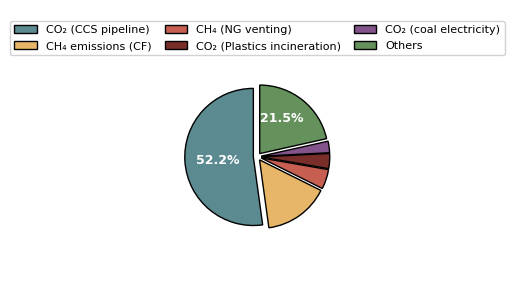

In [152]:
# Create pie chart for λ = 0.99 GSA results
plot_info_099 = unc_plots.plot_gsa_pie_chart(
    gsa_df_099, 
    figsize=(4.5, 6),
    results_dir=DIRECTORY,
    save_plot=True,
    show_plot=True,
    lambda_value=0.99,
)

if plot_info_099.get('pie_chart'):
    print(f"GSA pie chart for λ=0.99 saved to: {plot_info_099['pie_chart']}")

### Iteration 1: Biomass Expert Judgement

**Analysis Outcome & Motivation**
Initial analysis of the Pareto front reveals that negative impacts are overwhelmingly driven (>90%) by carbon content in sequential crops and manure. The system shows extreme sensitivity to these feedstock variables, favoring a technological pathway of **Biogas to Biomethane and SMR with CCS**. Consequently, the feasibility of this pathway hinges on the availability and modeling of biomass, which is currently treated with deterministic optimism.

**Addressing Epistemic Uncertainty**
To address this sensitivity, this iteration integrates epistemic uncertainty factors that challenge the stability of the biomass supply chain and its environmental accounting.

**1. Re-evaluating Biomass CO₂ Uptake (The Carbon Balance)**
Current models assume a perfect carbon balance where all field-captured CO₂ reaches the anaerobic digestion plant. We introduce uncertainty regarding:
* **Systemic Feedback:** The loss of soil carbon sequestration (humus formation) and nutrient retention when residues are removed rather than tilled.
* **Allocation Risks:** The potential for waste products (manure) to become economic drivers, locking in intensive, environmentally destructive farming practices.
* **Modeling Adjustment:** We inverse the probability distribution for CO₂ uptake. The upper bound is constrained to reflect losses during transport and the substitution cost of lost soil sequestration, pushing the realistic uptake closer to zero.

**2. Re-evaluating Biomass Feedstock Availability (Resource Criticality)**
We move beyond static availability to account for system-wide shocks and competition:
* **Competition:** High demand for biomass across sectors (heating, hydrogen, chemicals) may limit supply for ammonia production, forcing a regression to natural gas.
* **Supply Chain Volatility:** Risks include climate-induced crop failures, geopolitical instability, and a macroeconomic shift toward organic farming or lower-meat diets, which would drastically reduce residue and manure availability.
* **Modeling Adjustment:** We update variable bounds on biomass availability with triangular probability distributions to reflect this high resource criticality and insecurity.

Identify and extract metadata for CO₂ uptake intervention flows from anaerobic digestion processes to analyze epistemic uncertainty factors.

In [158]:
# Gets the descriptive names of the intervention flows for ammonia related processes
If_ammonia_unc = processor.rename_metadata_index(
    pd.DataFrame.from_records(pulpo_worker.uncertainty_data['If']['ammonia']['defined']).T, 
    pulpo_worker.lci_data, 
    'intervention_flow'
    )

# The intervention flows which might require special attention
If_names = [
    "anaerobic digestion of agricultural residues | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
    "anaerobic digestion of animal manure | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
    "anaerobic digestion of sequential crop | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')"
]

# Plotting the distributions of the selected intervention flows
matched_If_indcs = If_ammonia_unc.loc[If_names, 'index'].values
matched_If_unc_metadata = {indx:pulpo_worker.uncertainty_data['If']['ammonia']['defined'][indx] for indx in matched_If_indcs}
processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)


3 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


{(81, 23528): {'scale': 0.6968234915136446,
  'loc': 2.7924311285518777,
  'uncertainty_type': 3},
 (81, 23529): {'scale': 0.7007122031503241,
  'loc': 2.794592447848881,
  'uncertainty_type': 3},
 (81, 23530): {'scale': 0.7475485891148058,
  'loc': 2.8181447010306293,
  'uncertainty_type': 3}}

Extract variable bounds metadata for biomass processes to analyze resource criticality and supply chain uncertainty factors.

In [ ]:
# Gets the descriptive names of the variable bounds for the biomass related processeses
var_bounds_unc = processor.rename_metadata_index(
    pd.DataFrame.from_records(pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined']).T, 
    pulpo_worker.lci_data, 
    'process'
    )

# The flows which might require special attention
process_names = [
    "anaerobic digestion of agricultural residues | biogas | RER ",
    "anaerobic digestion of animal manure | biogas | RER ",
    "anaerobic digestion of sequential crop | biogas | RER "
]

# Plotting the distributions of the selected intervention flows
matched_process_indcs = var_bounds_unc.loc[process_names, 'index'].values
var_bounds_unc = var_bounds_unc.drop(columns=['index'])
matched_varbound_unc_metadata = {indx:pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined'][indx] for indx in matched_process_indcs}

Reverse probability distribution for CO₂ uptake to account for soil carbon loss and transport inefficiencies.

In [162]:
lower_scaling_factor = .5 #.9
upper_scaling_factor = .1
for indx, unc_metadata in matched_If_unc_metadata.items():
    matched_If_unc_metadata[indx]['minimum'] = unc_metadata['amount'] - unc_metadata['amount'] * lower_scaling_factor
    matched_If_unc_metadata[indx]['maximum'] = unc_metadata['amount'] + unc_metadata['amount'] * upper_scaling_factor
processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)


3 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


{(81, 23528): {'scale': 0.32092729159733824,
  'loc': 2.119039133443063,
  'uncertainty_type': 3},
 (81, 23529): {'scale': 0.3204839998149988,
  'loc': 2.119010710396602,
  'uncertainty_type': 3},
 (81, 23530): {'scale': 0.32089821511891814,
  'loc': 2.118342517091999,
  'uncertainty_type': 3}}

Implement epistemic uncertainty adjustments for biomass CO₂ uptake using expert knowledge strategy.

In [163]:
epistemic_unc_strategies_iteration_1 = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        prob_metadata=matched_If_unc_metadata
    )]
pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_1)

Applying uncertainy strategy ExpertKnowledgeStrategy, for ammonia in If
Var_bounds - upper_limit 
 	 25 parameters without uncertainty information


Set up triangular distributions for biomass feedstock availability to reflect resource criticality and supply volatility.

In [165]:
lower_multiplying_factor = .1
upper_multiplying_factor = 1.1
for indx, unc_metadata in matched_varbound_unc_metadata.items():
    matched_varbound_unc_metadata[indx]['minimum'] = unc_metadata['amount'] * lower_multiplying_factor
    matched_varbound_unc_metadata[indx]['maximum'] = unc_metadata['amount'] * upper_multiplying_factor
    matched_varbound_unc_metadata[indx]['loc'] = unc_metadata['amount']
    matched_varbound_unc_metadata[indx]['uncertainty_type'] = 5
processor.fit_normals(matched_varbound_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)

3 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


{23528: {'scale': 3596438309.4224796,
  'loc': 11738690729.895285,
  'uncertainty_type': 3},
 23529: {'scale': 4789895952.515976,
  'loc': 15624157261.891912,
  'uncertainty_type': 3},
 23530: {'scale': 3149120841.9000955,
  'loc': 10268387433.299597,
  'uncertainty_type': 3}}

Implement epistemic uncertainty for biomass feedstock availability using expert knowledge approach.

In [168]:
epistemic_unc_strategies_iteration_var_bounds = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        prob_metadata=matched_varbound_unc_metadata
    ),
    ]
pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_var_bounds)

Applying uncertainy strategy ExpertKnowledgeStrategy, for upper_limit in Var_bounds
Applying uncertainy strategy TriangluarBaseStrategy, for ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain') in Cf
Var_bounds - upper_limit 
 	 22 parameters without uncertainty information


Apply minimal uncertainty spread to unspecified variable bounds to ensure numerical stability.

In [170]:
var_bound_strategy = [processor.TriangluarBaseStrategy(
    uncertain_param_type='Var_bounds',
    uncertain_param_subgroup='upper_limit',
    upper_scaling_factor=.001,
    lower_scaling_factor=.001,
    noise_interval={'min':.05, 'max':.05}
)]
pulpo_worker.apply_uncertainty_strategies(strategies=var_bound_strategy)

Applying uncertainy strategy TriangluarBaseStrategy, for upper_limit in Var_bounds
No uncertainty data missing.


Generate chance-constrained formulation incorporating both environmental cost and variable bounds uncertainties.

In [171]:
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True, CC_var_bounds=['upper_limit'])

No uncertainty data missing.
No uncertainty data missing.
Transforming If-ecoinvent-3.10-cutoff to normal distribution
21607 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
21607 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming If-ammonia to normal distribution
57 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Cf-('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain') to normal distribution
59 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Var_bounds-upper_limit to normal distribution
25 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Var_bounds-lower_limit to normal distribution

#### Solve CC problem with epistemic uncertainties

Solve the chance-constrained optimization problem for lambda values from 0.5 to 0.9 with 0.1 increments to analyze the impact of epistemic uncertainty adjustments.

In [177]:
lambda_epsilon_array_it1 = np.arange(0.5, 1.0, 0.03)
results_CC_it1 = pulpo_worker.solve_CC_problem(lambda_epsilon_array_it1, normal_metadata_env_cost, normal_metadata_var_bounds, plot_results=False)

solving CC problem for lambda_QB = 0.5
Applying CC constraints to the environmental cost calculation with lambda: 0.5
Applying CC constraints to the upper_limit constraint with lambda: 0.5
optimal solution found:  -9360744907.635704
optimal solution found:  -9360744907.635704
solving CC problem for lambda_QB = 0.53
Applying CC constraints to the environmental cost calculation with lambda: 0.53
Applying CC constraints to the upper_limit constraint with lambda: 0.53
solving CC problem for lambda_QB = 0.53
Applying CC constraints to the environmental cost calculation with lambda: 0.53
Applying CC constraints to the upper_limit constraint with lambda: 0.53
optimal solution found:  -7568586700.547041
optimal solution found:  -7568586700.547041
solving CC problem for lambda_QB = 0.56
Applying CC constraints to the environmental cost calculation with lambda: 0.56
Applying CC constraints to the upper_limit constraint with lambda: 0.56
solving CC problem for lambda_QB = 0.56
Applying CC constra

#### Visualize epistemic uncertainty results

Generate Pareto front plot showing the impact of epistemic uncertainty adjustments on the trade-offs between cost and environmental performance.

In [223]:
importlib.reload(unc_plots)  # Ensure latest plotting code is used

<module 'a0_uncertainty_plots' from 'c:\\Users\\Fabian\\Documents\\Postdoc\\Python\\pulpo\\pulpo\\notebooks\\a0_uncertainty_plots.py'>

In [224]:
# --- Planetary Boundary Downscaling: Global GWP to EU Ammonia ---
"""
Calculates the annual CO2e budget for European Ammonia production
based on Absolute Environmental Sustainability Assessment (AESA) principles.

Methodology:
1. Global -> Region: Equal Per Capita (Population Share)
2. Region -> Sector: Economic Value Added (GDP Share)
3. Sector -> Product: Revenue Share
"""

# --- 1. Global Safe Operating Space (SOS) ---
# Source: Sala et al. (2020)
# Unit: kg CO2e / year
sos_global = 6.81e12 

# --- 2. Regional Share (Europe) ---
# Principle: Equal Per Capita
# Data: Eurostat (EU) / World Bank (Global) - approx 2023 figures
pop_global = 8.0e9      # 8.0 Billion
pop_eu = 448.0e6        # 448 Million

share_region = pop_eu / pop_global

# --- 3. Sector Share (Chemical Industry) ---
# Principle: Economic Value Added (Contribution to GDP)
# Data: Cefic Facts & Figures 2023
gdp_eu = 17.0e12        # ~€17 Trillion
gva_chemical = 165.0e9  # ~€165 Billion

share_sector = gva_chemical / gdp_eu

# --- 4. Product Share (Ammonia) ---
# Principle: Revenue Share (Turnover)
# Data: Cefic / Market Reports (Est. 17Mt prod * €600/t)
turnover_chemical = 655.0e9   # ~€655 Billion
revenue_ammonia = 10.2e9      # ~€10.2 Billion

share_product = 1 # revenue_ammonia / turnover_chemical

# --- 5. Final Calculation ---
limit_eu_ammonia = sos_global * share_region * share_sector * share_product

# --- Output Results ---
print(f"{'--- Downscaling Factors ---':<30}")
print(f"{'Global SOS:':<20} {sos_global/1e9:.2f} Gt CO2e")
print(f"{'EU Pop Share:':<20} {share_region:.2%}")
print(f"{'Chem Sector Share:':<20} {share_sector:.2%}")
print(f"{'Ammonia Rev Share:':<20} {share_product:.2%}")
print("-" * 30)
print(f"{'Final Annual Budget:':<20} {limit_eu_ammonia/1e6:.2f} Million kg CO2e")
print(f"{'Final Annual Budget:':<20} {limit_eu_ammonia/1e9:.5f} Million tonnes CO2e")

--- Downscaling Factors ---   
Global SOS:          6810.00 Gt CO2e
EU Pop Share:        5.60%
Chem Sector Share:   0.97%
Ammonia Rev Share:   100.00%
------------------------------
Final Annual Budget: 3701.44 Million kg CO2e
Final Annual Budget: 3.70144 Million tonnes CO2e


Generating Pareto front plot with epistemic uncertainty adjustments...


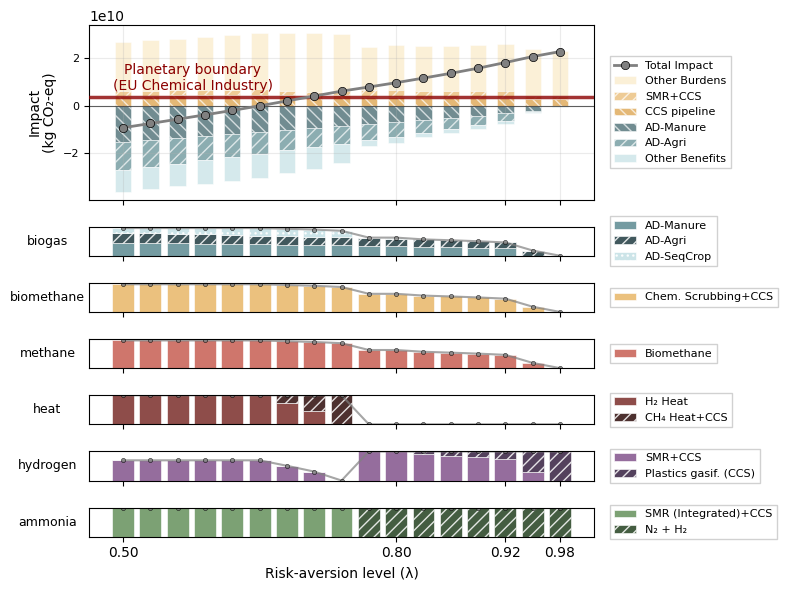

Epistemic uncertainty Pareto plot saved to: {'png': 'develop_tests\\pareto_and_choices_combined_it1.png', 'svg': 'develop_tests\\pareto_and_choices_combined_it1.svg'}


In [225]:
# Plot Pareto front results with epistemic uncertainties
print('Generating Pareto front plot with epistemic uncertainty adjustments...')
plot_path_it1 = unc_plots.plot_pareto_from_results(
    results_CC_it1, 
    results_dir=DIRECTORY, 
    lambda_range=(0.5, 1.0),
    legend_abbreviations=abbreviations,
    suffix='_it1',
    hline_y=limit_eu_ammonia,
)
print(f'Epistemic uncertainty Pareto plot saved to: {plot_path_it1}')

#### Global Sensitivity Analysis - Iteration 1

We perform Global Sensitivity Analysis for the epistemic uncertainty iteration to identify how the adjusted biomass uncertainties affect parameter sensitivity across different risk-aversion levels.

##### GSA Experiment 3: λ = 0.5 (Iteration 1)

In [226]:
# Create GSA worker for λ = 0.5 (Iteration 1)
pulpo_worker_gsa_it1_05 = deepcopy(pulpo_worker)

In [227]:
pulpo_worker_gsa_it1_05.import_and_filter_uncertainty_data(
    cutoff=0.000019,
    scaling_vector_strategy='naive',
    result_data=results_CC_it1[0.5],
    plot_results=False,
    plot_n_top_processes=19
)

# Apply all uncertainty strategies including epistemic adjustments
all_strategies_it1 = unc_strategies + epistemic_unc_strategies_iteration_1 + epistemic_unc_strategies_iteration_var_bounds + var_bound_strategy
pulpo_worker_gsa_it1_05.apply_uncertainty_strategies(strategies=all_strategies_it1)

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: -2.794519e+10
Characterized inventory: (2648, 23569) 19910
Filtered characterized inventory: (2648, 23569) 869
Deviation from LCA score: 0.008581182606785642
inventory (2648, 23569) filtering resulted in 869 of 19910 exchanges (99.14% of total impact) and took 0.002 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 26 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 774 
Parameters without uncertainty information: 71
In ammonia:
Parameters with uncertainty information: 774 
Parameters without uncertainty information: 71
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 24
Charactetization factors:
Parameters with uncertainty information: 14 
Parameters without uncertainty information: 12
Variable bounds:
Upper bound fro

In [228]:
total_Si_it1_05, sensitivity_indices_it1_05 = pulpo_worker_gsa_it1_05.run_gsa(
    result_data=results_CC_it1[0.5],
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=False,
    top_sensitivity_amt=20
)

No uncertainty data missing.
No uncertainty data missing.
Define the GSA problem...
problem includes:
869 uncertain intervention flows
26 uncertain characterization factors
Sample the GSA problem...


c:\Users\Fabian\miniconda3\envs\pulpo_unc\Lib\site-packages\scipy\stats\_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Run the model for all samples...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    1.792000e+05
mean    -2.328357e+09
std      1.134268e+10
min     -3.304242e+10
25%     -9.458959e+09
50%     -2.912639e+09
75%      5.926148e+09
max      3.370279e+10
dtype: float64
The deterministic impact is 1.0 : -9.360745e+09
(179200,)
the z-value of the total impact: 4.871536680257354
Analyze the GSA results...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    1.792000e+05
mean    -2.328357e+09
std      1.134268e+10
min     -3.304242e+10
25%     -9.458959e+09
50%     -2.912639e+09
75%      5.926148e+09
max      3.370279e+10
dtype: float64
The deterministic impact is 1.0 : -9.360745e+09
(179200,)
the z-value of the total impact: 4.871536680257354
Analyze the GSA results...
The total explained variance is 
81.63%
The total explained varia

##### GSA Experiment 4: λ = 0.74 (Iteration 1)

In [229]:
# Create GSA worker for λ = 0.74 (Iteration 1)
pulpo_worker_gsa_it1_074 = deepcopy(pulpo_worker)

In [231]:
pulpo_worker_gsa_it1_074.import_and_filter_uncertainty_data(
    cutoff=0.000019,
    scaling_vector_strategy='naive',
    result_data=results_CC_it1[0.7400000000000002],
    plot_results=False,
    plot_n_top_processes=19
)

pulpo_worker_gsa_it1_074.apply_uncertainty_strategies(strategies=all_strategies_it1)

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: -2.333748e+10
Characterized inventory: (2648, 23569) 20659
Filtered characterized inventory: (2648, 23569) 935
Deviation from LCA score: 0.008966394677242917
inventory (2648, 23569) filtering resulted in 935 of 20659 exchanges (99.1% of total impact) and took 0.002 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 26 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 840 
Parameters without uncertainty information: 70
In ammonia:
Parameters with uncertainty information: 840 
Parameters without uncertainty information: 70
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 25
Charactetization factors:
Parameters with uncertainty information: 14 
Parameters without uncertainty information: 12
Variable bounds:
Upper bound from

In [232]:
total_Si_it1_074, sensitivity_indices_it1_074 = pulpo_worker_gsa_it1_074.run_gsa(
    result_data=results_CC_it1[0.7400000000000002],
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=False,
    top_sensitivity_amt=20
)

No uncertainty data missing.
No uncertainty data missing.
Define the GSA problem...
problem includes:
935 uncertain intervention flows
26 uncertain characterization factors
Sample the GSA problem...


c:\Users\Fabian\miniconda3\envs\pulpo_unc\Lib\site-packages\scipy\stats\_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Run the model for all samples...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    1.924000e+05
mean    -7.329612e+07
std      9.421758e+09
min     -3.038454e+10
25%     -6.243210e+09
50%      2.009599e+08
75%      5.964959e+09
max      3.083162e+10
dtype: float64
The deterministic impact is 1.0 : 6.095367e+09
(192400,)
the z-value of the total impact: 128.54374011241313
Analyze the GSA results...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    1.924000e+05
mean    -7.329612e+07
std      9.421758e+09
min     -3.038454e+10
25%     -6.243210e+09
50%      2.009599e+08
75%      5.964959e+09
max      3.083162e+10
dtype: float64
The deterministic impact is 1.0 : 6.095367e+09
(192400,)
the z-value of the total impact: 128.54374011241313
Analyze the GSA results...
The total explained variance is 
98.72%
The total explained varia

##### GSA Experiment 5: λ = 0.8 (Iteration 1)

In [233]:
# Create GSA worker for λ = 0.8 (Iteration 1)
pulpo_worker_gsa_it1_08 = deepcopy(pulpo_worker)

In [234]:
pulpo_worker_gsa_it1_08.import_and_filter_uncertainty_data(
    cutoff=0.000019,
    scaling_vector_strategy='naive',
    result_data=results_CC_it1[0.8000000000000003],
    plot_results=False,
    plot_n_top_processes=19
)

pulpo_worker_gsa_it1_08.apply_uncertainty_strategies(strategies=all_strategies_it1)

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: -1.493717e+10
Characterized inventory: (2648, 23569) 19907
Filtered characterized inventory: (2648, 23569) 976
Deviation from LCA score: 0.009029679638102195
inventory (2648, 23569) filtering resulted in 976 of 19907 exchanges (99.1% of total impact) and took 0.002 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 868 
Parameters without uncertainty information: 84
In ammonia:
Parameters with uncertainty information: 868 
Parameters without uncertainty information: 84
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 24
Charactetization factors:
Parameters with uncertainty information: 15 
Parameters without uncertainty information: 12
Variable bounds:
Upper bound from

In [235]:
total_Si_it1_08, sensitivity_indices_it1_08 = pulpo_worker_gsa_it1_08.run_gsa(
    result_data=results_CC_it1[0.8000000000000003],
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=False,
    top_sensitivity_amt=20
)

No uncertainty data missing.
No uncertainty data missing.
Define the GSA problem...
problem includes:
976 uncertain intervention flows
27 uncertain characterization factors
Sample the GSA problem...


c:\Users\Fabian\miniconda3\envs\pulpo_unc\Lib\site-packages\scipy\stats\_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Run the model for all samples...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    2.008000e+05
mean     2.167336e+09
std      7.510686e+09
min     -1.798687e+10
25%     -3.019413e+09
50%      2.245706e+09
75%      7.425032e+09
max      2.612717e+10
dtype: float64
The deterministic impact is 1.0 : 9.670983e+09
(200800,)
the z-value of the total impact: 3.4653991937373445
Analyze the GSA results...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    2.008000e+05
mean     2.167336e+09
std      7.510686e+09
min     -1.798687e+10
25%     -3.019413e+09
50%      2.245706e+09
75%      7.425032e+09
max      2.612717e+10
dtype: float64
The deterministic impact is 1.0 : 9.670983e+09
(200800,)
the z-value of the total impact: 3.4653991937373445
Analyze the GSA results...
The total explained variance is 
112.2%
The total explained varia

##### GSA Experiment 6: λ = 0.98 (Iteration 1)

In [249]:
# Create GSA worker for λ = 0.98 (Iteration 1)
pulpo_worker_gsa_it1_098 = deepcopy(pulpo_worker)

In [254]:
pulpo_worker_gsa_it1_098.import_and_filter_uncertainty_data(
    cutoff=0.0000019,
    scaling_vector_strategy='naive',
    result_data=results_CC_it1[0.9800000000000004],
    plot_results=False,
    plot_n_top_processes=19
)


pulpo_worker_gsa_it1_098.apply_uncertainty_strategies(strategies=unc_strategies + epistemic_unc_strategies_iteration_var_bounds + var_bound_strategy)

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 1.482197e+10
Characterized inventory: (2648, 23569) 20727
Filtered characterized inventory: (2648, 23569) 2020
Deviation from LCA score: 0.0014041768576759095
inventory (2648, 23569) filtering resulted in 2020 of 20727 exchanges (99.86% of total impact) and took 0.001 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 31 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 1827 
Parameters without uncertainty information: 191
In ammonia:
Parameters with uncertainty information: 1827 
Parameters without uncertainty information: 191
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 2
Charactetization factors:
Parameters with uncertainty information: 15 
Parameters without uncertainty information: 16
Variable bounds:
Upper boun

In [255]:
total_Si_it1_098, sensitivity_indices_it1_098 = pulpo_worker_gsa_it1_098.run_gsa(
    result_data=results_CC_it1[0.9800000000000004],
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=False,
    top_sensitivity_amt=20
)

No uncertainty data missing.
No uncertainty data missing.
Define the GSA problem...
problem includes:
2020 uncertain intervention flows
31 uncertain characterization factors
Sample the GSA problem...


c:\Users\Fabian\miniconda3\envs\pulpo_unc\Lib\site-packages\scipy\stats\_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Run the model for all samples...
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    4.104000e+05
mean     1.654631e+10
std      6.986016e+08
min      1.457136e+10
25%      1.602705e+10
50%      1.661194e+10
75%      1.706169e+10
max      1.888152e+10
dtype: float64
The deterministic impact is 1.0 : 2.281585e+10
(410400,)
the z-value of the total impact: 0.04222099193985599
The statistics of the the sample impacts: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
count    4.104000e+05
mean     1.654631e+10
std      6.986016e+08
min      1.457136e+10
25%      1.602705e+10
50%      1.661194e+10
75%      1.706169e+10
max      1.888152e+10
dtype: float64
The deterministic impact is 1.0 : 2.281585e+10
(410400,)
the z-value of the total impact: 0.04222099193985599
Analyze the GSA results...
Analyze the GSA results...
The total explained variance is 
107.5%
The total explained var

## Bar Charts with Variance Whiskers

In [302]:
importlib.reload(unc_plots)  # Ensure latest plotting code is used
importlib.reload(unc_utils)  # Ensure latest utility code is used

<module 'a0_uncertainty_utils' from 'c:\\Users\\Fabian\\Documents\\Postdoc\\Python\\pulpo\\pulpo\\notebooks\\a0_uncertainty_utils.py'>

c:\Users\Fabian\Documents\Postdoc\Python\pulpo\pulpo\notebooks\a0_uncertainty_utils.py:141: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


GSA Results - Iteration 1, λ = 0.50:
Global Sensitivity Analysis Results - Top Parameters:
             Short_Label       ST   S1
  CO₂ uptake (AD-Manure) 0.267404 None
      CH₄ emissions (CF) 0.245810 None
CO₂ emission (AD-Manure) 0.074653 None
CH₄ emission (AD-Manure) 0.054379 None
    CO₂ uptake (AD-Agri) 0.037779 None
       CO₂ (AD-Agri Res) 0.034445 None
       CO₂ (AD-Seq Crop) 0.034262 None
       CH₄ (AD-Agri Res) 0.029582 None
      CO₂ (CCS pipeline) 0.011756 None
                  Others 0.209928 None

Sum of top parameters ST values: 0.7901
Remaining contribution: 0.2099


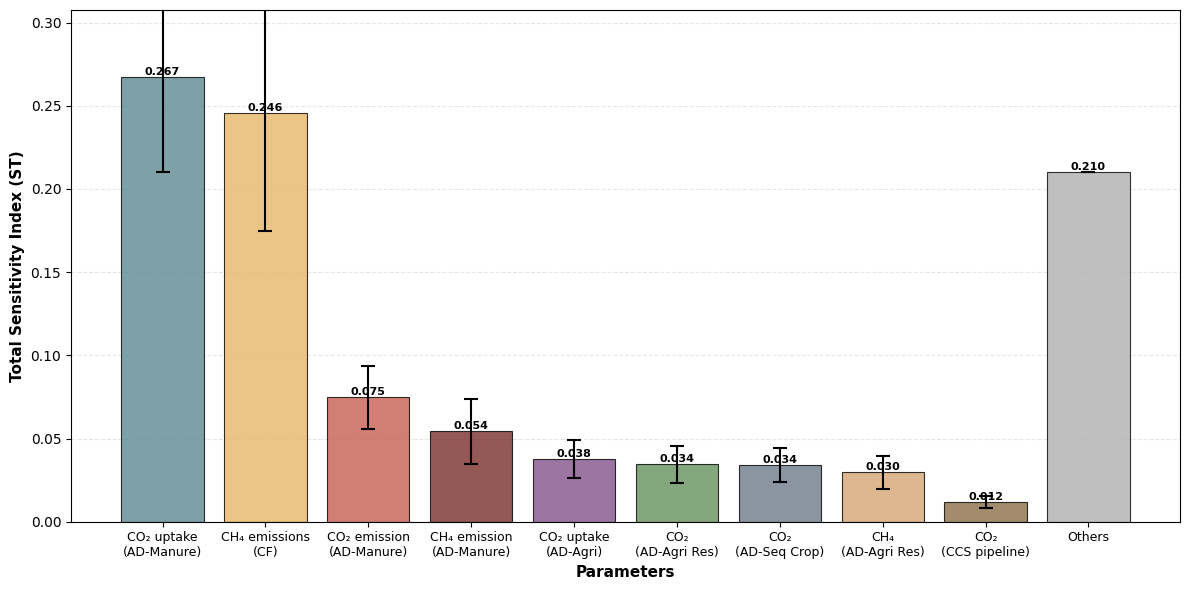


Bar charts saved:
  PNG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.50.png
  SVG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.50.svg

Bar charts saved:
  PNG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.50.png
  SVG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.50.svg


In [303]:
# Bar chart for λ = 0.50
gsa_df_it1_05, sum_st_it1_05, remaining_it1_05 = unc_utils.process_gsa_results(total_Si_it1_05, inv_map, proc_map, top_n=9)
print("GSA Results - Iteration 1, λ = 0.50:")
unc_plots.print_gsa_summary(gsa_df_it1_05, print_mapping_reference=False)

bar_chart_paths_it1_05 = unc_plots.plot_gsa_bar_chart(
    total_Si_it1_05, 
    inv_map, 
    proc_map, 
    results_dir=DIRECTORY, 
    figsize=(12, 6), 
    save_plot=True, 
    show_plot=True, 
    lambda_value=0.50,
    top_n=9
)
print(f"\nBar charts saved:\n  PNG: {bar_chart_paths_it1_05['png']}\n  SVG: {bar_chart_paths_it1_05['svg']}")
print(f"\nBar charts saved:\n  PNG: {bar_chart_paths_it1_05['png']}\n  SVG: {bar_chart_paths_it1_05['svg']}")

c:\Users\Fabian\Documents\Postdoc\Python\pulpo\pulpo\notebooks\a0_uncertainty_utils.py:141: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


GSA Results - Iteration 1, λ = 0.74:
Global Sensitivity Analysis Results - Top Parameters:
             Short_Label       ST   S1
      CH₄ emissions (CF) 0.270454 None
  CO₂ uptake (AD-Manure) 0.253153 None
    CO₂ uptake (AD-Agri) 0.104855 None
       CO₂ (AD-Seq Crop) 0.091888 None
CO₂ emission (AD-Manure) 0.067414 None
CH₄ emission (AD-Manure) 0.043995 None
       CO₂ (AD-Agri Res) 0.036467 None
       CH₄ (AD-Agri Res) 0.033557 None
       CO₂ (AD-Seq Crop) 0.030475 None
                  Others 0.067744 None

Sum of top parameters ST values: 0.9323
Remaining contribution: 0.0677


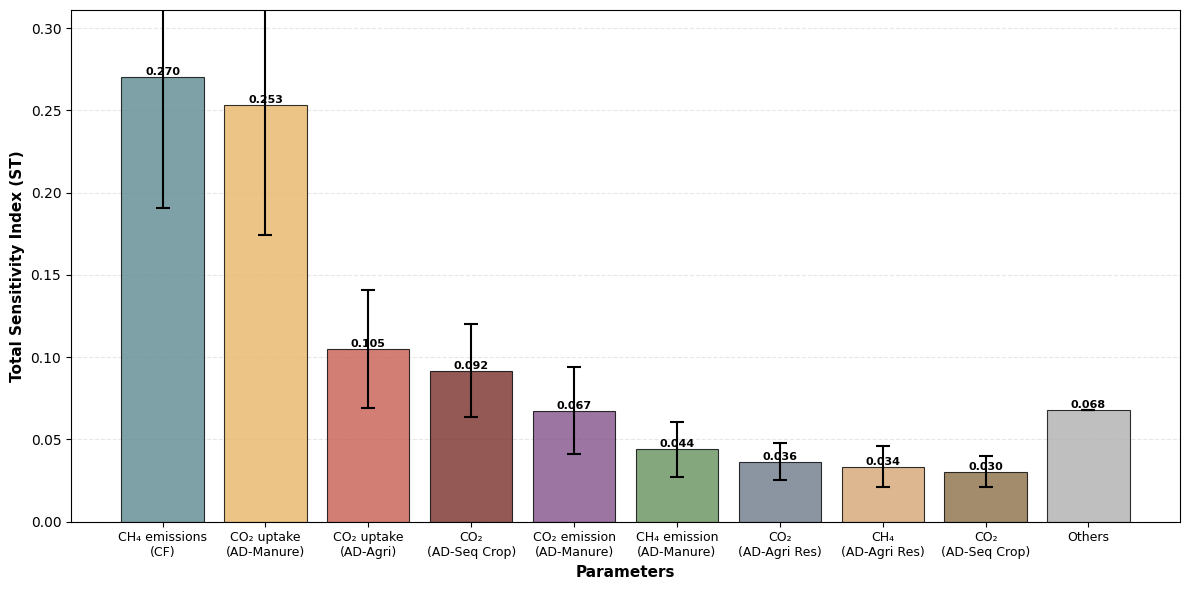


Bar charts saved:
  PNG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.74.png
  SVG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.74.svg


In [301]:
# Bar chart for λ = 0.74
gsa_df_it1_074, sum_st_it1_074, remaining_it1_074 = unc_utils.process_gsa_results(total_Si_it1_074, inv_map, proc_map, top_n=9)
print("GSA Results - Iteration 1, λ = 0.74:")
unc_plots.print_gsa_summary(gsa_df_it1_074, print_mapping_reference=False)

bar_chart_paths_it1_074 = unc_plots.plot_gsa_bar_chart(
    total_Si_it1_074, 
    inv_map, 
    proc_map, 
    results_dir=DIRECTORY, 
    figsize=(12, 6), 
    save_plot=True, 
    show_plot=True, 
    lambda_value=0.74,
    top_n=9
)
print(f"\nBar charts saved:\n  PNG: {bar_chart_paths_it1_074['png']}\n  SVG: {bar_chart_paths_it1_074['svg']}")

c:\Users\Fabian\Documents\Postdoc\Python\pulpo\pulpo\notebooks\a0_uncertainty_utils.py:141: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


GSA Results - Iteration 1, λ = 0.80:
Global Sensitivity Analysis Results - Top Parameters:
                                   Short_Label        ST   S1
                        CO₂ uptake (AD-Manure)  0.342957 None
                            CH₄ emissions (CF)  0.237490 None
                          CO₂ uptake (AD-Agri)  0.194396 None
                      CO₂ emission (AD-Manure)  0.132786 None
                      CH₄ emission (AD-Manure)  0.070111 None
                             CO₂ (AD-Agri Res)  0.054387 None
                             CH₄ (AD-Agri Res)  0.053196 None
Carbon dioxide (steam methane reforming (CCS))  0.013558 None
                            CO₂ (CCS pipeline)  0.010181 None
                                        Others -0.109062 None

Sum of top parameters ST values: 1.1091
Remaining contribution: -0.1091


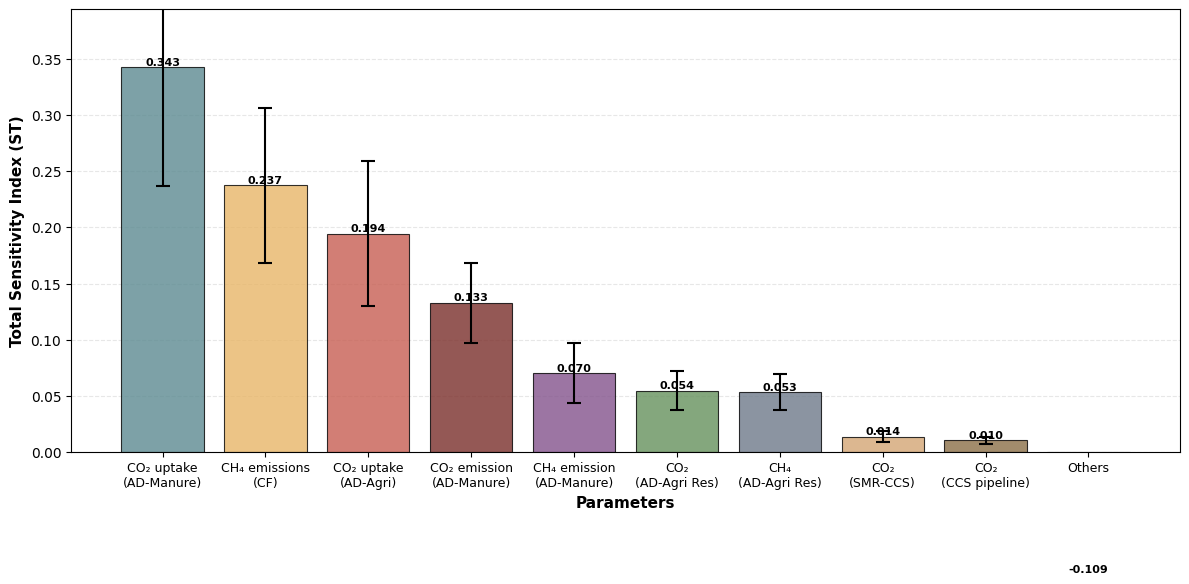


Bar charts saved:
  PNG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.80.png
  SVG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.80.svg


In [299]:
# Bar chart for λ = 0.80
gsa_df_it1_08, sum_st_it1_08, remaining_it1_08 = unc_utils.process_gsa_results(total_Si_it1_08, inv_map, proc_map, top_n=9)
print("GSA Results - Iteration 1, λ = 0.80:")
unc_plots.print_gsa_summary(gsa_df_it1_08, print_mapping_reference=False)

bar_chart_paths_it1_08 = unc_plots.plot_gsa_bar_chart(
    total_Si_it1_08, 
    inv_map, 
    proc_map, 
    results_dir=DIRECTORY, 
    figsize=(12, 6), 
    save_plot=True, 
    show_plot=True, 
    lambda_value=0.80,
    top_n=9
)
print(f"\nBar charts saved:\n  PNG: {bar_chart_paths_it1_08['png']}\n  SVG: {bar_chart_paths_it1_08['svg']}")

In [300]:
importlib.reload(unc_plots)  # Ensure latest plotting code is used
importlib.reload(unc_utils)  # Ensure latest utility code is used

<module 'a0_uncertainty_utils' from 'c:\\Users\\Fabian\\Documents\\Postdoc\\Python\\pulpo\\pulpo\\notebooks\\a0_uncertainty_utils.py'>

c:\Users\Fabian\Documents\Postdoc\Python\pulpo\pulpo\notebooks\a0_uncertainty_utils.py:141: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


GSA Results - Iteration 1, λ = 0.98:
Global Sensitivity Analysis Results - Top Parameters:
                      Short_Label       ST   S1
               CO₂ (CCS pipeline) 0.590853 None
               CH₄ emissions (CF) 0.172860 None
                 CH₄ (NG venting) 0.044917 None
      CO₂ (Plastics incineration) 0.037794 None
              CO₂ (lignite elec.) 0.027185 None
           CO₂ (coal electricity) 0.026763 None
                  CO₂ (transport) 0.022305 None
                 CO₂ (NG turbine) 0.019252 None
Carbon dioxide (sawing, softwood) 0.017080 None
                           Others 0.040990 None

Sum of top parameters ST values: 0.9590
Remaining contribution: 0.0410


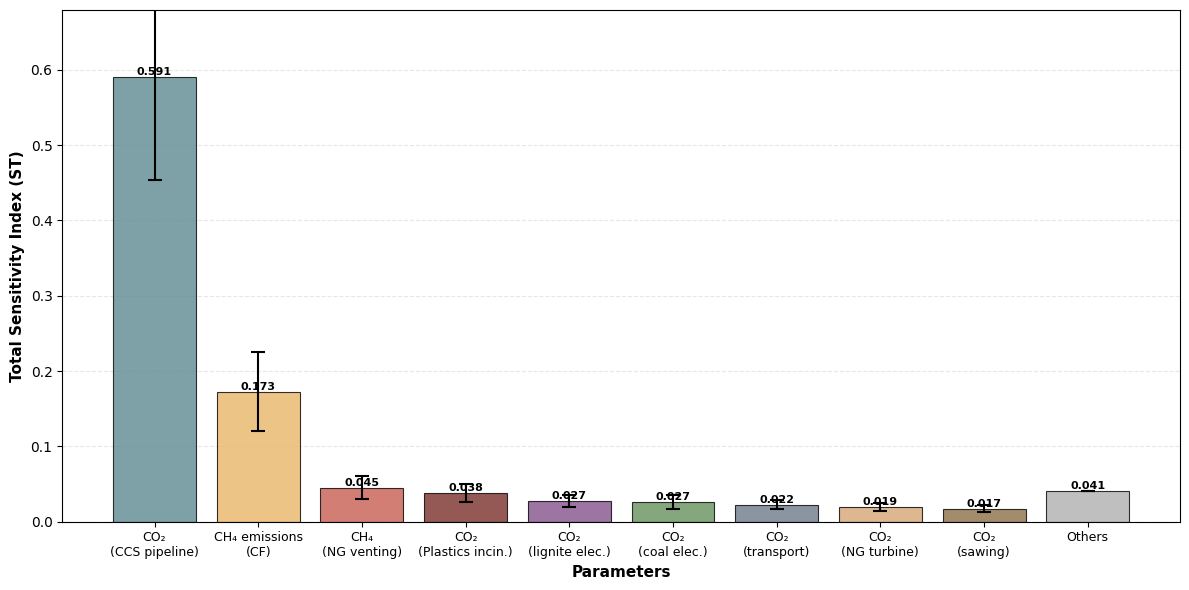


Bar charts saved:
  PNG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.98.png
  SVG: develop_tests\gsa_sensitivity_bar_chart_lambda_0.98.svg


In [297]:
# Bar chart for λ = 0.98
gsa_df_it1_098, sum_st_it1_098, remaining_it1_098 = unc_utils.process_gsa_results(total_Si_it1_098, inv_map, proc_map, top_n=9)
print("GSA Results - Iteration 1, λ = 0.98:")
unc_plots.print_gsa_summary(gsa_df_it1_098, print_mapping_reference=False)

bar_chart_paths_it1_098 = unc_plots.plot_gsa_bar_chart(
    total_Si_it1_098, 
    inv_map, 
    proc_map, 
    results_dir=DIRECTORY, 
    figsize=(12, 6), 
    save_plot=True, 
    show_plot=True, 
    lambda_value=0.98,
    top_n=9
)
print(f"\nBar charts saved:\n  PNG: {bar_chart_paths_it1_098['png']}\n  SVG: {bar_chart_paths_it1_098['svg']}")